<a href="https://colab.research.google.com/github/Neeraja-577/Machine-Learning/blob/main/ML_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Business Problem Understanding

The objective of this project is to predict medical insurance expenses based on individual characteristics such as age, sex, BMI, number of children, smoking status, and region.

 Insurance companies need accurate cost predictions to set fair premiums and reduce financial risks.

 By analyzing historical data, this project builds a regression model to estimate expenses and identify key cost-driving factors.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

# 2.Data Collection

In [ ]:
df=pd.read_csv('/content/CO2 Emissions_Canada.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
df.shape

(7385, 12)

In [ ]:
df.size

88620

In [ ]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


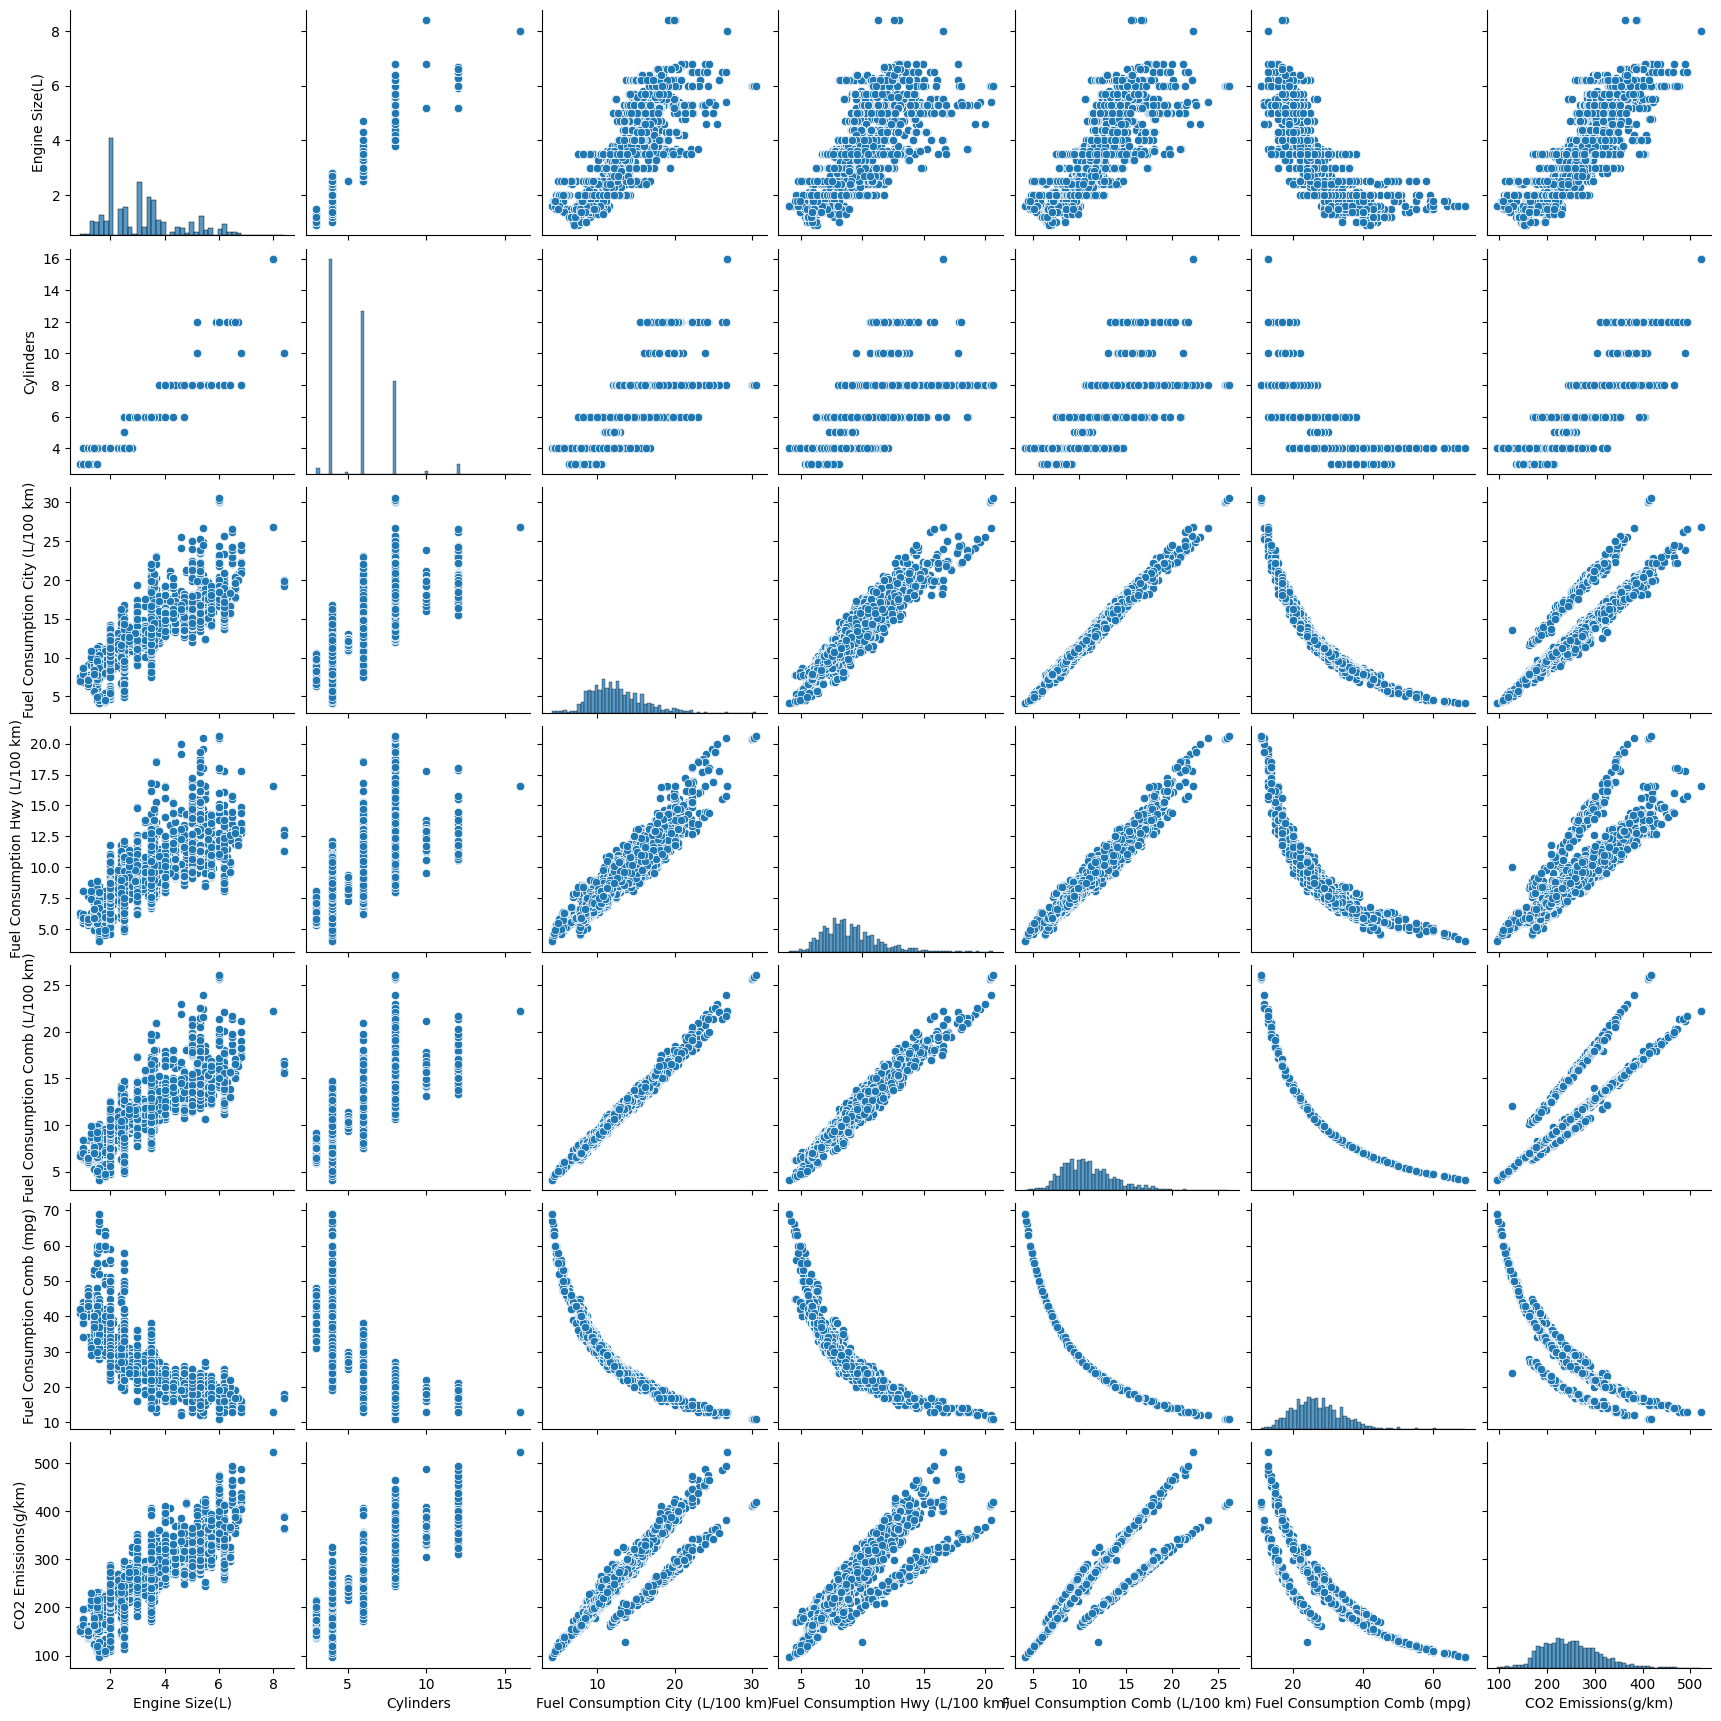

In [ ]:
sns.pairplot(df)
plt.show()

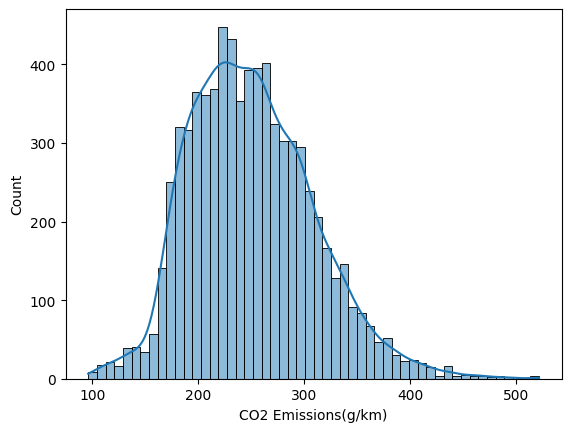

In [ ]:
# Distribution
sns.histplot(df['CO2 Emissions(g/km)'], kde=True)
plt.show()

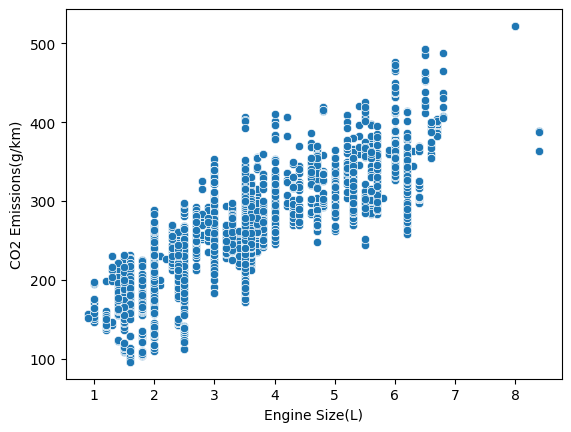

In [ ]:
# Engine size vs CO2
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df)
plt.show()

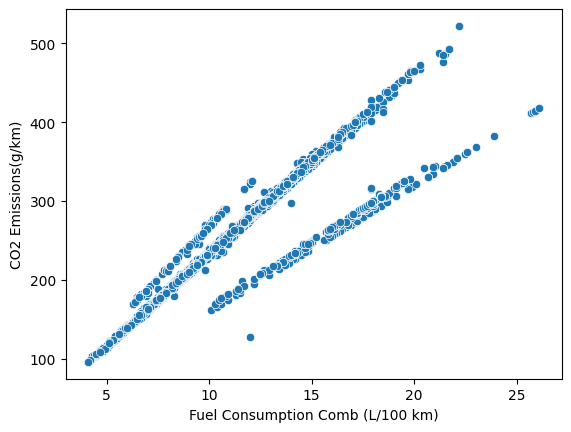

In [ ]:
# Fuel consumption vs CO2
sns.scatterplot(x='Fuel Consumption Comb (L/100 km)',
                y='CO2 Emissions(g/km)', data=df)
plt.show()


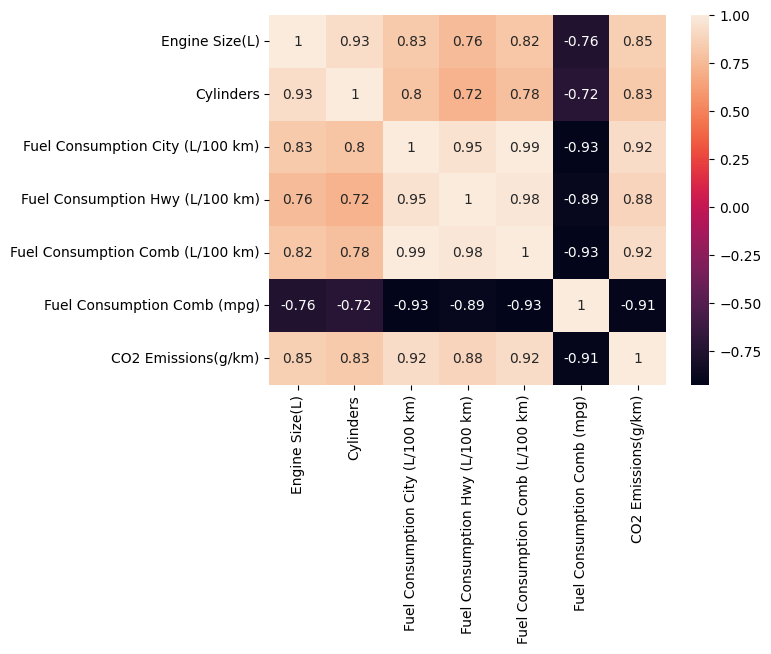

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7380,False
7381,False
7382,False
7383,False


In [ ]:
print(df['Engine Size(L)'].unique())

[2.  2.4 1.5 3.5 3.7 1.8 5.9 4.7 3.  4.  6.3 4.2 5.2 6.  6.8 4.4 3.6 1.4
 2.5 6.2 4.3 5.3 4.8 1.2 5.7 6.4 4.6 5.4 1.6 5.  1.  5.8 3.8 3.3 5.6 3.2
 6.5 5.5 2.1 3.4 2.7 6.6 6.7 1.3 8.4 2.3 2.8 0.9 2.9 8.  2.2]


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Apply encoding on Fuel Type
df['Fuel Type'] = le.fit_transform(df['Fuel Type'])

# View encoded values
print(df[['Fuel Type']].head())

   Fuel Type
0          4
1          4
2          4
3          4
4          4


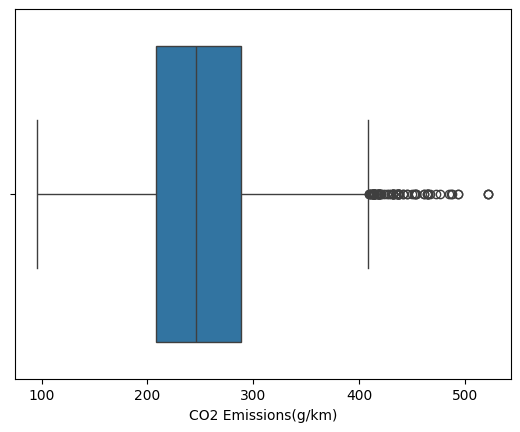

In [ ]:
sns.boxplot(x=df['CO2 Emissions(g/km)'])
plt.show()

In [ ]:
!pip install  feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
from feature_engine.outliers import Winsorizer
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['CO2 Emissions(g/km)'])
df_win=win.fit_transform(df[['CO2 Emissions(g/km)']])
df_win

,CO2 Emissions(g/km)
0,196
1,221
2,136
3,255
4,244
...,...
7380,219
7381,232
7382,240
7383,232


In [ ]:
print(win.left_tail_caps_,win.right_tail_caps_)

{'CO2 Emissions(g/km)': 88.0} {'CO2 Emissions(g/km)': 408.0}


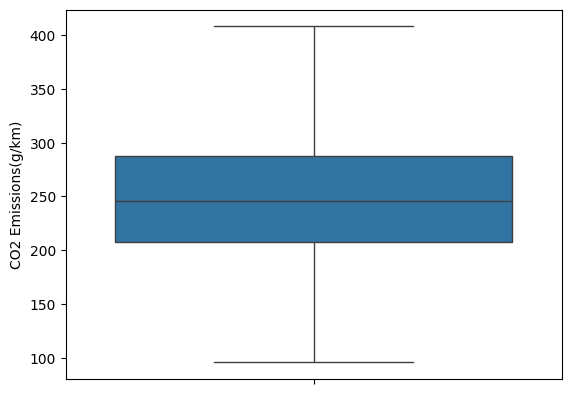

In [ ]:
sns.boxplot(df_win['CO2 Emissions(g/km)'])
plt.show()

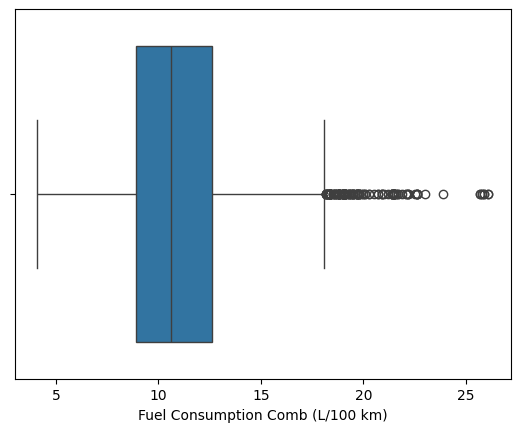

In [ ]:

sns.boxplot(x=df['Fuel Consumption Comb (L/100 km)'])
plt.show()

In [ ]:
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['Fuel Consumption Comb (L/100 km)'])
df_win=win.fit_transform(df[['Fuel Consumption Comb (L/100 km)']])
df_win

,Fuel Consumption Comb (L/100 km)
0,8.5
1,9.6
2,5.9
3,11.1
4,10.6
...,...
7380,9.4
7381,9.9
7382,10.3
7383,9.9


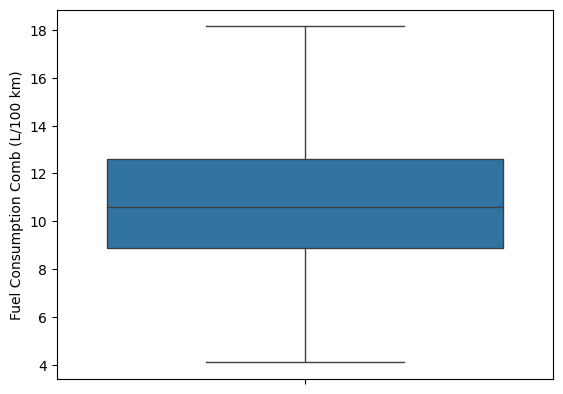

In [ ]:
sns.boxplot(df_win['Fuel Consumption Comb (L/100 km)'])
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

object_columns=df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col]=df[col].astype(str)

for col in object_columns:
    df[col]=le.fit_transform(df[col])

print(df.head())

   Engine Size(L)  Cylinders  Transmission  Fuel Type  \
0             2.0          4            14          4   
1             2.4          4            25          4   
2             1.5          4            22          4   
3             3.5          6            15          4   
4             3.5          6            15          4   

   Fuel Consumption Comb (L/100 km)  CO2 Emissions(g/km)  
0                               8.5                  196  
1                               9.6                  221  
2                               5.9                  136  
3                              11.1                  255  
4                              10.6                  244  


In [ ]:
X = df.drop("CO2 Emissions(g/km)", axis=1)
y = df["CO2 Emissions(g/km)"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape,X_test.shape

((5908, 5), (1477, 5))

In [ ]:
from sklearn.linear_model import LinearRegression




In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:


lr.intercept_

np.float64(19.038674570334763)

In [ ]:
lr.coef_

array([ 6.00712104,  3.56594426, -0.15241253, 10.32299821, 14.67344127])

* Linear

In [ ]:
train_predictions=lr.predict(X_train)

In [ ]:
test_predictions=lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
print('MAE for test data:',mean_absolute_error(y_test,test_predictions))
print('MAE for train data:',mean_absolute_error(y_train,train_predictions))

MAE for test data: 12.934489450300624
MAE for train data: 12.424413680372288


In [ ]:
from sklearn.metrics import r2_score
print('R2 for test data:',r2_score(y_test,test_predictions))
print('R2 for train data:',r2_score(y_train,train_predictions))

R2 for test data: 0.8930026633730593
R2 for train data: 0.899868725843382


In [ ]:
lr.score(X_test,y_test)

0.8930026633730593

In [ ]:
lr.score(X_train,y_train)

0.899868725843382

In [ ]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(model,X_train,y_train,cv=5)
print(score)

cv_score=score.mean()
print("Cross validation score:",cv_score)

[0.89282642 0.89632701 0.89261505 0.90689983 0.90680645]
Cross validation score: 0.899094952773555


In [ ]:
test_res=y_test-test_predictions

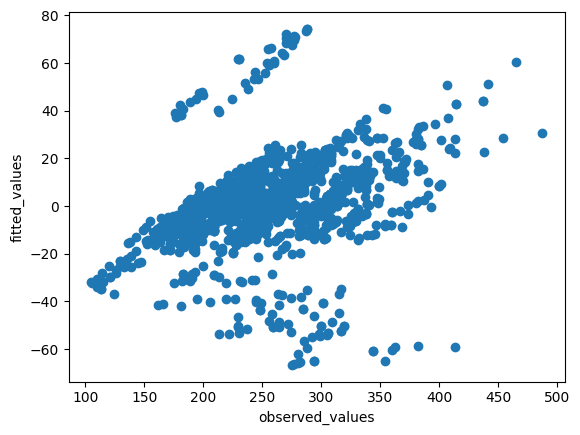

In [ ]:
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

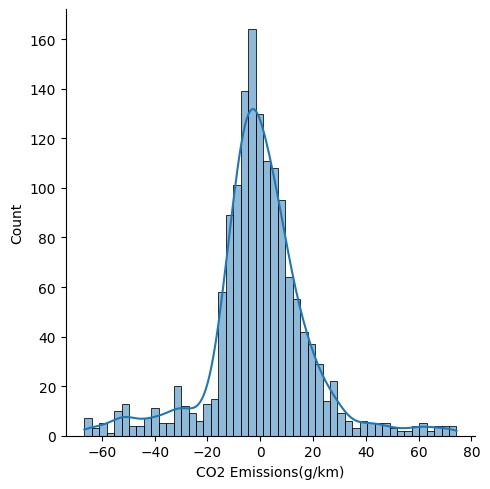

In [ ]:
sns.displot(test_res,kde=True)

 #plt.hist(test_res)

plt.show()

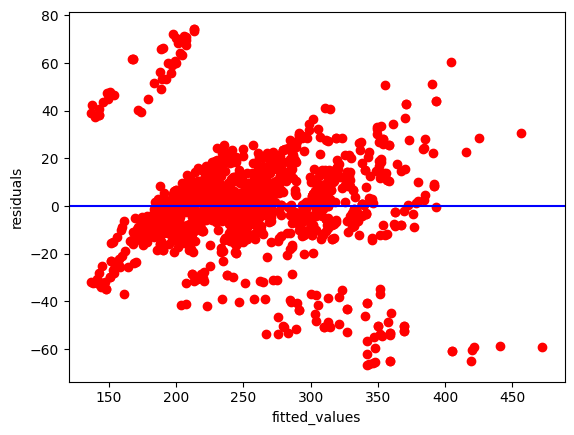

In [ ]:
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

In [ ]:
import statsmodels.formula.api as smf
model2=smf.ols('y~X',data=df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                 1.307e+04
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:11:39   Log-Likelihood:                -32081.
No. Observations:                7385   AIC:                         6.417e+04
Df Residuals:                    7379   BIC:                         6.422e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.7974      1.454     13.619      0.000      16.948      22.647
X[0]           5.9111      0.471     12.547      0.000       4.988       6.835
X[1]           3.8126      0.328     11.607      0.000       3.169       4.456
X[2]          -0.1384      0.033     -4.218      0.000      -0.203      -0.074
X[3]           9.9465      0.266     37.367      0.000       9.425      10.468
X[4]          14.5963      0.137    106.501      0.000      14.328      14.865
==============================================================================
Omnibus:                      648.314   Durbin-Watson:                   1.682
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4278.166
Skew:                          -0.081   Prob(JB):                         0.00
Kurtosis:                       6.725   Cond. No.                         135.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* Polynomial

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
X_train=pd.DataFrame(polynomial_converter.fit_transform(X_train))
X_test=pd.DataFrame(polynomial_converter.fit_transform(X_test))

In [ ]:
X_train.shape,X_test.shape

((5908, 20), (1477, 20))

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
model.intercept_

np.float64(135.7869872694596)

In [ ]:
model.coef_

array([ 2.23278935e+01,  1.04896964e+01, -8.38659787e-01, -4.20100895e+01,
        4.29329335e-01,  7.35397817e-01, -2.23908524e+00, -1.86134026e-01,
       -5.36807286e+00,  7.96618603e-01,  1.85260683e+00,  1.38050696e-01,
       -2.79626439e+00, -1.59894502e+00, -8.12401611e-04,  1.35120219e-01,
        1.25239728e-02, -8.81552424e-01,  7.50812334e+00,  1.23352270e-01])

In [ ]:
train_pred=model.predict(X_train)
test_pred=model.predict(X_test)

In [ ]:
model.score(X_train, y_train)

0.9745977506270276

In [ ]:
model.score(X_test,y_test)

0.9756188798451986

In [ ]:
X_train.shape,X_test.shape

((5908, 20), (1477, 20))

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,X_train ,y_train,cv=5)
print(scores)
scores.mean()

[0.97111288 0.97381894 0.97479601 0.97814952 0.97224292]


np.float64(0.9740240551187342)

In [ ]:
train_r2=[]
test_r2=[]

for i in range(1,10):
    from sklearn.preprocessing import PolynomialFeatures
    polynomial_converter=PolynomialFeatures(degree=i,include_bias=False)
    X_poly=polynomial_converter.fit_transform(X)
    X_poly=pd.DataFrame(X_poly)

    from sklearn.model_selection import train_test_split
    X_train,X_test,y_train,y_test=train_test_split(X_poly,y,test_size=0.3,random_state=40)


    from sklearn.linear_model import LinearRegression
    model=LinearRegression()
    model.fit(X_train,y_train)

    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_r2.append(model.score(X_train, y_train))
    test_r2.append(model.score(X_test,y_test))

In [ ]:
train_r2

[0.8968594841171882,
 0.9736946559689734,
 0.9972125030942333,
 0.9977128072662048,
 0.9978728008732242,
 0.9981084701113638,
 0.9983101266653214,
 0.9984178940494923,
 0.9984829273358805]

In [ ]:
test_r2

[0.9022367571645585,
 0.9774842753484815,
 0.9974892991724401,
 0.9978961768846194,
 0.9977453405220041,
 0.9953960654311229,
 0.1452685655387148,
 0.8347497998584096,
 -19.04330749457001]

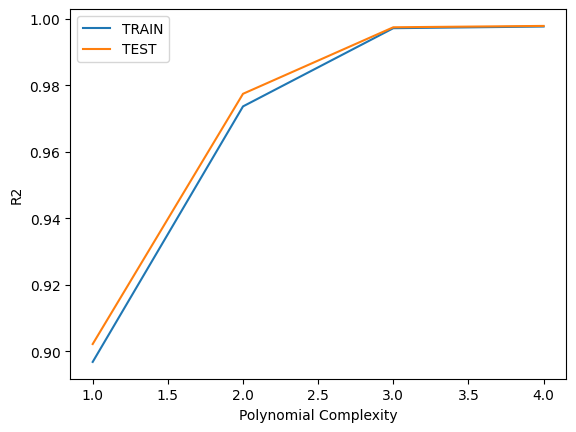

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 5), train_r2[:4], label='TRAIN')
plt.plot(range(1, 5), test_r2[:4], label='TEST')

plt.xlabel("Polynomial Complexity")
plt.ylabel("R2")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,X_train ,y_train,cv=5)
print(scores)
scores.mean()

[0.99328241 0.99131261 0.99286277 0.99499589 0.99255983]


np.float64(0.9930026999972152)

* Lasso

In [ ]:
#modelling

from sklearn.linear_model import Lasso
lasso_base=Lasso()
lasso_base.fit(X_train,y_train)

#predictions

train_predictions=lasso_base.predict(X_train)
test_predictions=lasso_base.predict(X_test)

#evaluation

print("Train R2:",lasso_base.score(X_train,y_train))
print("Test R2:",lasso_base.score(X_test,y_test))

from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(lasso_base,X,y,cv=5).mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.408e+04, tolerance: 1.772e+03
  model = cd_fast.enet_coordinate_descent(


Train R2: 0.9945609025924974
Test R2: 0.9948242516607058
Cross validation score: 0.8922536119286131


In [ ]:
X=X.drop(X.columns[[1]],axis=1)
y=df['CO2 Emissions(g/km)']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=9)

#Modelling
from sklearn.linear_model import Lasso
lasso_base=Lasso(alpha=100)
lasso_base.fit(X_train,y_train)

#predictions
train_predictions=lasso_base.predict(X_train)
test_predictions=lasso_base.predict(X_test)

#evaluation
print("Train R2:",lasso_base.score(X_train,y_train))
print("Test R2:",lasso_base.score(X_test,y_test))
print("Cross validation score:",cross_val_score(lasso_base,X,y,cv=5).mean())

Train R2: 0.48524974510734165
Test R2: 0.47792495816987457
Cross validation score: 0.4893947572317002


* Ridge

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
X = df.drop("CO2 Emissions(g/km)", axis=1)
y = df["CO2 Emissions(g/km)"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
ridge = Ridge(alpha=1.0)  # alpha = regularization strength

ridge.fit(X_train_scaled, y_train)

y_pred = ridge.predict(X_test_scaled)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))


print("R2 Score:", r2_score(y_test, y_pred))

MAE: 12.937064255213613
R2 Score: 0.8930080639200512


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(Ridge(), params, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print("Best Alpha:", ridge_cv.best_params_)

Best Alpha: {'alpha': 10}


* elastic

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [ ]:
X = df.drop("CO2 Emissions(g/km)", axis=1)
y = df["CO2 Emissions(g/km)"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train_scaled, y_train)

y_pred = elastic.predict(X_test_scaled)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 13.672082068914916
MSE: 372.4599513277474
RMSE: 19.29922152128804
R2 Score: 0.8917150300192456


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}

elastic_cv = GridSearchCV(ElasticNet(), params, cv=5)
elastic_cv.fit(X_train_scaled, y_train)

print("Best Parameters:", elastic_cv.best_params_)

Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.8}


* save

In [ ]:
from joblib import dump

In [ ]:
dump(model,'insurance_model.joblib')

['insurance_model.joblib']

In [ ]:
from joblib import load

In [ ]:
loaded_model=load('insurance_model.joblib')

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("CO2 Emissions_Canada.csv")

df = df.drop(['Make', 'Model', 'Vehicle Class'], axis=1)

df = pd.get_dummies(df, drop_first=True)

# Clean column names
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '')
df.columns = df.columns.str.replace(')', '')


X = df.drop("CO2_Emissionsg/km", axis=1)
y = df["CO2_Emissionsg/km"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


def evaluate_model(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    cv_score = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2').mean()

    return [name, train_mse, test_mse, train_r2, test_r2, cv_score]


results = []

# Linear Regression
results.append(evaluate_model("Linear", LinearRegression(),
                             X_train_scaled, X_test_scaled))

# Ridge
results.append(evaluate_model("Ridge", Ridge(alpha=1.0),
                             X_train_scaled, X_test_scaled))

# Lasso
results.append(evaluate_model("Lasso", Lasso(alpha=0.1),
                             X_train_scaled, X_test_scaled))

# ElasticNet
results.append(evaluate_model("ElasticNet",
                             ElasticNet(alpha=0.1, l1_ratio=0.5),
                             X_train_scaled, X_test_scaled))

# Polynomial Regression
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

results.append(evaluate_model("Polynomial",
                             LinearRegression(),
                             X_train_poly, X_test_poly))


columns = ["Algorithm", "Train MSE", "Test MSE",
           "Train R2", "Test R2", "CV Score"]

results_df = pd.DataFrame(results, columns=columns)


print(results_df)


results_df.to_csv("model_comparison.csv", index=False)

    Algorithm  Train MSE   Test MSE  Train R2   Test R2  CV Score
0      Linear  23.269612  33.108837  0.993193  0.990374  0.993003
1       Ridge  23.270783  33.061531  0.993193  0.990388  0.993004
2       Lasso  24.300912  33.146713  0.992891  0.990363  0.992711
3  ElasticNet  45.009414  51.035452  0.986834  0.985163  0.986608
4  Polynomial   6.563026  18.967710  0.998080  0.994486  0.997661
